# 14.1.1 从快照到截断奇异值

## 学习目标与先修知识

从训练快照建立低秩（rank）表示，计算投影（projection）误差，并判断能量比例能否证明动态预测有效。

先修：3.2 向量（vector）与矩阵（matrix）；6.4 最小二乘；8.3 变量尺度与训练评估划分。

## 具体问题

三间相通的容室在几个时刻各存有多少物质？将每个时刻的三个总量排成一列，能否用少数方向概括整组快照？高重建精度又能否保证新的初值（initial condition）预测准确？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先对只有两个独立方向的人工矩阵做奇异值分解（singular value decomposition，SVD），观察第三个方向是否确实没有数据。

In [2]:
X_demo=np.array([[3.,0.,3.],[0.,2.,2.],[0.,0.,0.]])
U_demo,s_demo,Vt_demo=np.linalg.svd(X_demo,full_matrices=False)
print('奇异值：',np.round(s_demo,6))
print('秩2重建误差：',np.linalg.norm(X_demo-U_demo[:,:2]@U_demo[:,:2].T@X_demo))

奇异值： [4.561825 2.278102 0.      ]
秩2重建误差： 7.078796907375567e-16


## 模型假设

快照矩阵的列是同一变量、同一单位下不同时刻的所追踪物质总量（tracked amount），行是容室；快照来自训练轨迹（trajectory）。若各行单位或尺度不同，先由训练数据确定转换并对评估数据沿用；本节的三个变量均为 U。中心化均值只从训练列求得，不能把留出轨迹用于求基。

## 数学解释与推导

令训练快照矩阵 $X=[x_1,\ldots,x_m]\in\mathbb R^{n\times m}$。奇异值分解 $X=U\Sigma V^\mathsf T$ 中，$U$ 的列正交（orthogonality），非负奇异值（singular value） $\sigma_1\ge\sigma_2\ge\cdots$。取前 $r$ 列 $U_r$，投影矩阵 $P_r=U_rU_r^\mathsf T$，重建 $\hat X=P_rX$。以这些方向对快照作最小平方重建，也称本征正交分解（proper orthogonal decomposition，POD）；此处的基是从训练数据提取的，不是已证实的生理机制。正交性给出 $\|X-\hat X\|_F^2=\sum_{j>r}\sigma_j^2$；相同条件下这也是秩不超过 $r$ 的最小 Frobenius 重建误差。**奇异值平方占比** $\sum_{j\le r}\sigma_j^2/\sum_j\sigma_j^2$ 是保留模式的奇异值平方和占全部平方和的比例。本节把平方和形象地称为数据“能量”，用来表示这些数据模式的总体强度。例如奇异值为 3 和 1 时，总平方和为 $3^2+1^2=10$，只保留第一模式的占比为 90%。它不一定是真实物理能量；90% 的数据能量也不意味着未来预测准确率为 90%。后文简称能量占比。$r=0$ 时 $P_r=0$，$r$ 达到矩阵秩时训练残差（residual）为零。单个奇异向量可整体改号而不改变投影；若截断恰好穿过重复奇异值，最优投影子空间也可能不唯一，但最小重建误差仍由舍弃奇异值确定。

## 核心实现

把上述步骤写成可检查的函数；算法在此处完整展示。

In [3]:
def svd_project(snapshots, rank):
    """Project columns onto the first rank left-singular directions."""
    data = np.asarray(snapshots, dtype=float)
    left, values, _ = np.linalg.svd(data, full_matrices=False)
    basis = left[:, :rank]
    projection = basis @ basis.T
    rebuilt = projection @ data
    residual = float(np.linalg.norm(data - rebuilt, ord='fro'))
    return [rebuilt.tolist(), projection.tolist(), residual]


def centered_basis(snapshots, rank):
    """Fit mean and orthonormal basis on training columns only."""
    data = np.asarray(snapshots, dtype=float)
    mean = np.mean(data, axis=1)
    left, values, _ = np.linalg.svd(data - mean[:, None], full_matrices=False)
    return mean, left[:, :rank], values


def exchange_exact(laplacian, initial, times):
    """Exact trajectory for a symmetric closed exchange matrix."""
    lap = np.asarray(laplacian, dtype=float)
    eigenvalues, eigenvectors = np.linalg.eigh(lap)
    x0 = np.asarray(initial, dtype=float)
    weights = eigenvectors.T @ x0
    return np.array([eigenvectors @ (np.exp(-eigenvalues * t) * weights) for t in times])


def diffusion_step(state, alpha):
    """Conservative five-cell-style no-flux neighbor exchange on any 1D grid."""
    old = np.asarray(state, dtype=float)
    updated = old.copy()
    for i in range(len(old)):
        left = old[i-1] if i > 0 else old[i]
        right = old[i+1] if i+1 < len(old) else old[i]
        updated[i] = old[i] + alpha * (left - 2*old[i] + right)
    return updated

## 对照实验

在无外部输入（input）的三室对称交换模型（model）中，从同一训练初值产生快照；只用训练列拟合均值与方向。将训练重建误差与留出初值的投影误差并列；再以第 12 篇的无通量五格扩散作为第二组小快照，检查同一个截断定理。

C:\Users\10149\AppData\Local\Temp\ipykernel_39912\1312899362.py:14: UserWarning: The figure layout has changed to tight
  axes[1].legend();plt.tight_layout();plt.show()


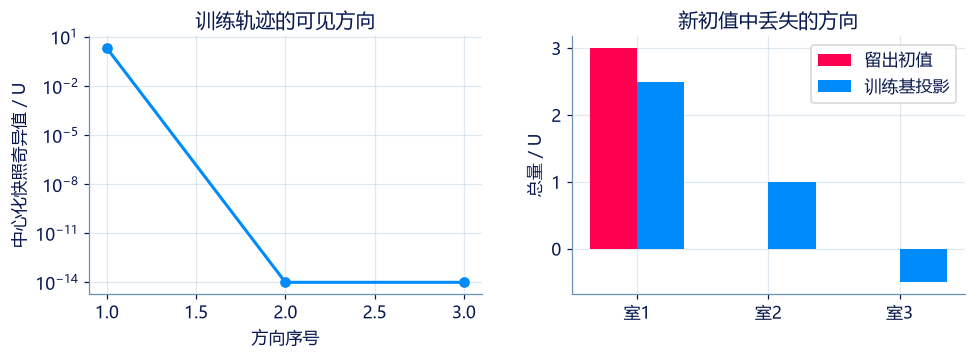

训练重建误差 3.6703930624096264e-15 ；留出初值投影误差 1.2247448713915898
五格扩散秩 1 训练重建残差 3.207744 ；舍弃奇异值核验 3.207744
五格扩散秩 2 训练重建残差 1.156317 ；舍弃奇异值核验 1.156317


In [4]:
L=np.array([[1.,-1.,0.],[-1.,2.,-1.],[0.,-1.,1.]])
times=np.linspace(0,6,31)
train=exchange_exact(L,[2.,1.,0.],times).T
held_initial=np.array([3.,0.,0.])
mean,basis,singular=centered_basis(train,1)
train_error=np.linalg.norm(train-(mean[:,None]+basis@basis.T@(train-mean[:,None])))
held_projection=mean+basis@basis.T@(held_initial-mean)
fig,axes=plt.subplots(1,2,figsize=(9,3.4))
axes[0].semilogy(range(1,len(singular)+1),np.maximum(singular,1e-14),'o-',color=BLUE)
axes[0].set(xlabel='方向序号',ylabel='中心化快照奇异值 / U',title='训练轨迹的可见方向')
axes[1].bar(np.arange(3)-.18,held_initial,width=.36,label='留出初值',color=PINK)
axes[1].bar(np.arange(3)+.18,held_projection,width=.36,label='训练基投影',color=BLUE)
axes[1].set(xticks=range(3),xticklabels=['室1','室2','室3'],ylabel='总量 / U',title='新初值中丢失的方向')
axes[1].legend();plt.tight_layout();plt.show()
print('训练重建误差',train_error,'；留出初值投影误差',np.linalg.norm(held_initial-held_projection))
five=np.array([3.,0.,0.,0.,0.]);diffusion=[five.copy()]
for _ in range(30):
    five=diffusion_step(five,.2);diffusion.append(five.copy())
diffusion=np.asarray(diffusion).T
singular_diffusion=np.linalg.svd(diffusion,compute_uv=False)
for rank in (1,2):
    _,_,residual=svd_project(diffusion.tolist(),rank)
    print('五格扩散秩',rank,'训练重建残差',round(residual,6),'；舍弃奇异值核验',round(np.linalg.norm(singular_diffusion[rank:]),6))

## 结果解释

训练轨迹几乎只沿一个中心化方向变化，所以秩1重建很准；新初值含训练没有激发的快模态（mode），投影立即失去该部分。图中留出初值只用于评价，不参与选择基。五格扩散提供另一组守恒快照，也可用相同截断关系比较重建误差。

### 独立核对

在人工矩阵上独立核对舍弃奇异值平方和；检查秩零与满秩边界及投影幂等性。

In [5]:
for rank in [0,1,2,3]:
    rebuilt,P,residual=svd_project(X_demo.tolist(),rank)
    np.testing.assert_allclose(residual**2,sum(s_demo[rank:]**2),atol=1e-10)
    np.testing.assert_allclose(np.asarray(P)@np.asarray(P),P,atol=1e-10)
assert train_error<1e-10
assert np.linalg.norm(held_initial-held_projection)>.5
np.testing.assert_allclose(diffusion.sum(axis=0),3.,atol=1e-12)
for rank in (1,2):
    np.testing.assert_allclose(svd_project(diffusion.tolist(),rank)[2],np.linalg.norm(singular_diffusion[rank:]),atol=1e-10)
print('截断误差、投影和留出方向核验通过。')

截断误差、投影和留出方向核验通过。


[在本章探索中改变截断秩与初值](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/explore/)：先预测，再检查重建和留出误差。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：截断 SVD 的投影重建

snapshots 的每一列是同一时刻的 n 维状态（state）。取其前 rank 个左奇异方向，返回投影（projection）后的快照、n×n 投影矩阵（matrix）和 Frobenius 残差（residual）范数（norm）；比较结果按投影矩阵而不是单个奇异向量（vector）符号判定。

**函数与代码模板**

```python
def solve(
    snapshots: list[list[float]],
    rank: int,
) -> tuple[list[list[float]], list[list[float]], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `snapshots` | `list[list[float]]` | n×m 训练快照矩阵；每一行表示同一变量。 | U |
| `rank` | `int` | 截断秩（rank），允许0，且不大于 min(n,m)。 | 个 |

**返回值**

按以下顺序返回元组：(reconstruction, projection, residual)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `reconstruction` | `list[list[float]]` | 投影后的 n×m 快照矩阵。 | U |
| `projection` | `list[list[float]]` | 投影到所选左奇异子空间的 n×n 矩阵。 | 1 |
| `residual` | `float` | 原快照减重建快照的 Frobenius 范数。 | U |

**计算规则**

直接对题给快照做 SVD，不中心化；rank=0 时返回全零重建和投影。奇异向量改号不改变投影；本题不在重复奇异值（singular value）中截断。用 numpy.linalg.svd。

**约束与边界**

- 输入（input）矩阵有限；按照给定秩与顺序返回普通 Python 列表及浮点数。
- n≥m≥1；快照矩阵列满秩。若 0<rank<m，则截断处 σ_rank>σ_(rank+1)，不在重复奇异值中截断。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| snapshots | n×m 训练快照矩阵；每一行表示同一变量。 | [[3.0, 0.0], [0.0, 2.0]] | U |
| rank | 截断秩（rank），允许0，且不大于 min(n,m)。 | 1 | 个 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
snapshots = [[3.0, 0.0], [0.0, 2.0]]
rank = 1

result = solve(snapshots, rank)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| reconstruction | 投影后的 n×m 快照矩阵。 | [[3.0, 0.0], [0.0, 0.0]] | U |
| projection | 投影到所选左奇异子空间的 n×n 矩阵。 | [[1.0, 0.0], [0.0, 0.0]] | 1 |
| residual | 原快照减重建快照的 Frobenius 范数。 | 2 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[3.0, 0.0], [0.0, 0.0]],
                   [[1.0, 0.0], [0.0, 0.0]],
                   2.0)
```

**样例解释**

首例只保留第一坐标方向，重建 [[3,0],[0,0]]，残差为2；奇异向量整体改号不改变投影。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：截断 SVD 的投影重建](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/practice/?question=p14-svd-reconstruction)

### 第 2 题 · 单项选择题：高能量比例意味着什么

训练快照的首个奇异值（singular value）平方占总平方和的99%。这能单独保证什么？

- **A.** 训练快照在该方向的最优秩（rank）1 Frobenius 重建误差平方占约1%。
- **B.** 任意新初值（initial condition）的长期预测误差都不超过1%。
- **C.** 该奇异向量（vector）一定是真实系统唯一的机制变量。
- **D.** 不用说明变量尺度，也可以比较不同单位的能量。

[作答：高能量比例意味着什么](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/practice/?question=p14-energy-limit)

### 第 3 题 · 单项选择题：基应从哪些轨迹取得

目标是检查用训练轨迹（trajectory）得到的低秩（rank）基能否预测新初值（initial condition）。如何划分数据？

- **A.** 仅用训练轨迹求中心与基；新初值轨迹只用于评估。
- **B.** 先把新初值完整轨迹加入 SVD，再报告其重建误差为零。
- **C.** 看完留出误差后反复选择最有利的秩，却仍称其为独立测试。
- **D.** 不同容室使用不同物理单位而不声明转换。

[作答：基应从哪些轨迹取得](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/practice/?question=p14-holdout-basis)

### 第 4 题 · 单项选择题：奇异向量改号后的判定

两个 SVD 程序得到首个左奇异向量（vector） u 与 −u，但奇异值（singular value）相同。哪项结论成立？

- **A.** 两者给出相同的 uuᵀ 投影（projection）矩阵（matrix）。
- **B.** 至少一个程序的重建必错误。
- **C.** 两个投影必互为相反数。
- **D.** 首个奇异值会变成负数。

[作答：奇异向量改号后的判定](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/practice/?question=p14-sign-and-rank)

**进一步阅读**

[Boyd 与 Vandenberghe 的应用线性代数教材](https://web.stanford.edu/~boyd/vmls/)可复习 SVD 与低秩近似；本节交换模型与训练划分已完整定义。